### Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt
import statistics
from scipy import stats
from colorama import Fore
from sklearn.mixture import BayesianGaussianMixture
from scipy.stats import norm


# Read in data

### Decide if splitting sets or not

In [3]:
split = False # learning persists over sets

if split:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data_split.csv")
    raw_df.set_index('subject_trial', inplace=True)
else:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data.csv")
    raw_df.set_index('subject', inplace=True)

### Decide for all or only small

In [4]:
small_only = True # switching up between big and small created inconsistency

if small_only:
    raw_df = raw_df.drop(raw_df.filter(like='big', axis=1), axis=1)

print(raw_df.shape[1])

30


### Plot all the raw data

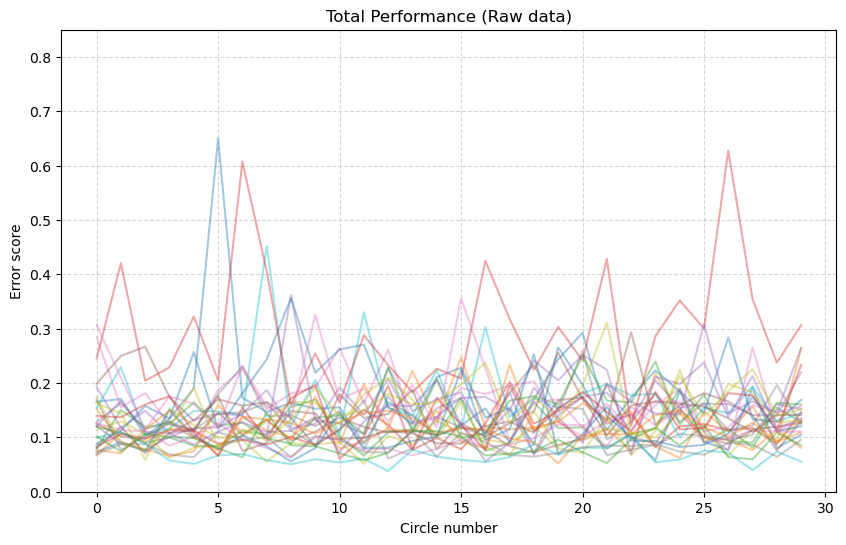

In [5]:
plt.figure(figsize=(10, 6))
for i, row in raw_df.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Circle number")
plt.ylabel("Error score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Clean up the data by removing outliers

In [6]:
# want to have fewer outliers for learning - more difficult to determine
std_dev = 2.5 # how many standard deviations from the mean data can be

# calculate z scores
z_scores = (raw_df - raw_df.mean()) / raw_df.std()

# replace values with NaN if they’re more than determined standard deviations from the mean
df_clean = raw_df.mask(np.abs(z_scores) > std_dev)

# fill NaN with the median of that column instead of dropping
df_clean = df_clean.apply(lambda x: x.fillna(x.median()), axis=0)

#### Visualize cleaned up data

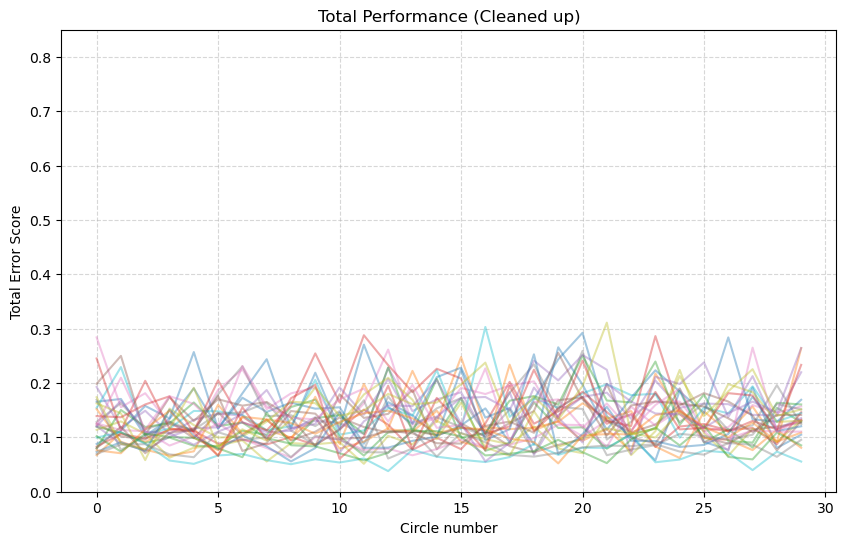

In [7]:
plt.figure(figsize=(10, 6))
for i, row in df_clean.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Circle number")
plt.ylabel("Total Error Score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Determine percentage change at various window sizes

## Make function to calculate the change

In [8]:
def get_change(start, end):
    difference = end - start
    change = difference / start
    percent_change = change * 100
    return percent_change

## Calculate each percentage change

In [9]:
if not small_only:
    window_sizes = [4, 8, 12, 16, 20, 40]
else:
    window_sizes = [5, 10, 15, 30] # good balance of short and long term

percent_dict = {}

for window in window_sizes:
    all_percents = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            start_val = errors[start]

            end_val = errors[start + window - 1]

            all_percents.append(get_change(start_val, end_val))

    percent_dict[window] = np.array(all_percents)

### Plot each percentage change

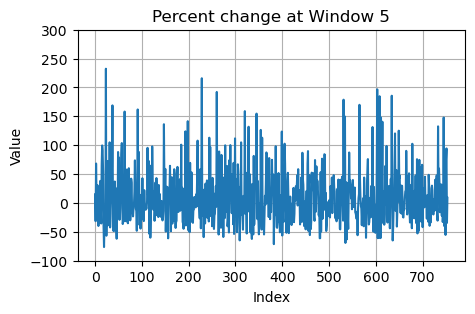

Number of percent samples: 754


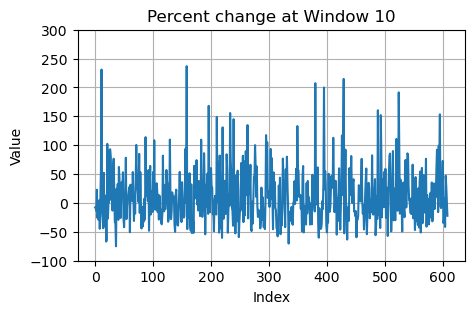

Number of percent samples: 609


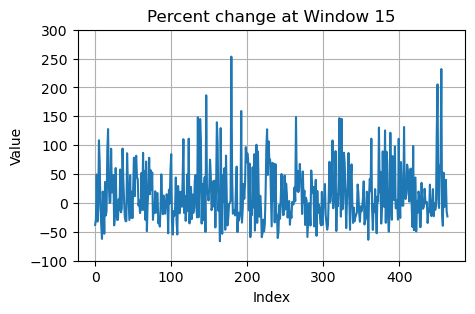

Number of percent samples: 464


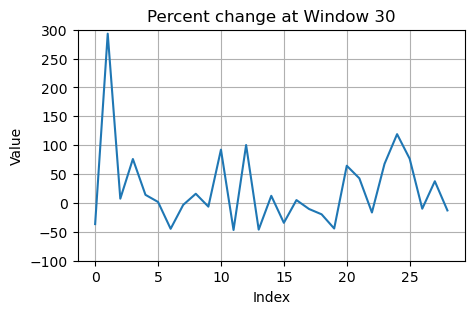

Number of percent samples: 29


In [10]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percent change at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

### Clean up and remove outliers

In [11]:
# want to have fewer outliers for learning - more difficult to determine
std_dev = 2.5  # how many standard deviations from the mean data can be

# replace outliers with median for each window
percent_dict_cleaned = {}

for window, percents in percent_dict.items():
    # calculate z-scores
    mean = np.nanmean(percents)
    std = np.nanstd(percents)
    z_scores = (percents - mean) / std
    
    # replace values with NaN if they're more than std_dev standard deviations from mean
    percents_masked = np.where(np.abs(z_scores) > std_dev, np.nan, percents)
    
    # fill NaN with the median
    median = np.nanmedian(percents_masked)
    percents_cleaned = np.where(np.isnan(percents_masked), median, percents_masked)
    
    percent_dict_cleaned[window] = percents_cleaned
    
    # print replacement statistics
    n_replaced = np.sum(np.abs(z_scores) > std_dev)
    pct_replaced = 100 * n_replaced / len(percents)
    print(f"Window {window}: Replaced {n_replaced} outliers ({pct_replaced:.1f}%) with median {median:.4f}")

# use cleaned data for downstream analysis
percent_dict = percent_dict_cleaned

Window 5: Replaced 22 outliers (2.9%) with median -0.1592
Window 10: Replaced 15 outliers (2.5%) with median 3.5426
Window 15: Replaced 11 outliers (2.4%) with median 2.9287
Window 30: Replaced 1 outliers (3.4%) with median 3.3809


#### Plot cleaned up percent changes

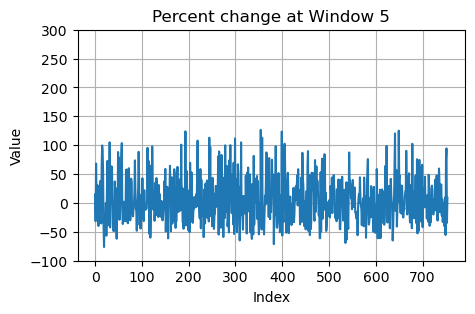

Number of percent samples: 754


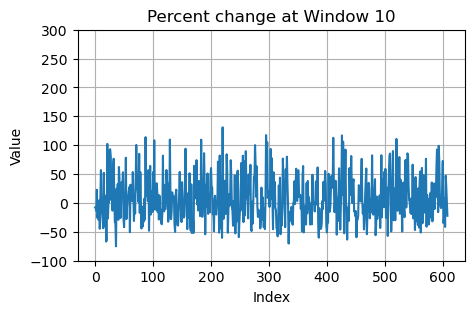

Number of percent samples: 609


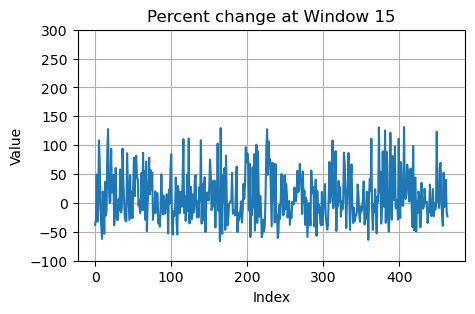

Number of percent samples: 464


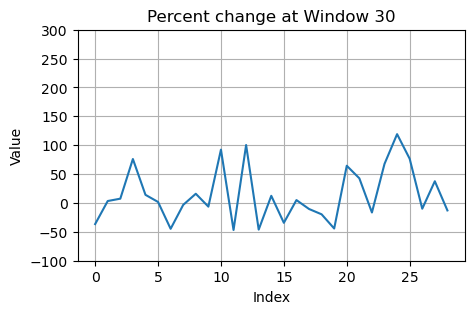

Number of percent samples: 29


In [12]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percent change at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

# Use Gaussian Mixture Model to label

## Find thresholds for given probability

In [13]:
desired_probability = 0.85

In [17]:
conf_percent = str(desired_probability * 100) + "%"
thresholds = {}
gmm_results = {}

for window, percent in percent_dict.items():
    percents_reshaped = percent.reshape(-1, 1) # reshape the percents
    gmm = BayesianGaussianMixture(n_components=3, n_init=1000, tol=0.001) # create GMM
    gmm.fit(percents_reshaped) # fit the GMM to the data
    
    # sort components
    means = gmm.means_.flatten()

    sigmas = np.sqrt(gmm.covariances_.flatten())

    order = np.argsort(means)
    means, sigmas, weights = means[order], sigmas[order], gmm.weights_[order]
    
    # compute posteriors over value range
    x = np.linspace(np.min(percent), np.max(percent), 10000)
    # probability distribution function
    pdfs = np.array([w * norm.pdf(x, m, s) for w, m, s in zip(weights, means, sigmas)])
    posteriors = pdfs / np.sum(pdfs, axis=0)
    
    # confidence thresholds
    # learning group is index 0
    learning_cutoff = x[np.where(posteriors[0] >= desired_probability)[0][-1]] if np.any(posteriors[0] >= desired_probability) else np.nan
    # fatigue group is index 2
    fatigue_cutoff = x[np.where(posteriors[2] >= desired_probability)[0][0]] if np.any(posteriors[2] >= desired_probability) else np.nan

    thresholds[window] = {
        "learning_cutoff": learning_cutoff,
        "fatigue_cutoff": fatigue_cutoff,
        "means": means,
    }
    gmm_results[window] = {"means": means, "sigmas": sigmas, "weights": weights}

# display thresholds
for w, t in thresholds.items():
    print(f"Window {w}:")
    print(f"  {conf_percent} Learning cutoff: {t['learning_cutoff']:.4f}")
    print(f"  {conf_percent} Fatigue cutoff: {t['fatigue_cutoff']:.4f}")


random_point = np.random.choice(percent)
prob = gmm.predict_proba([[random_point]])[0]
print(f"\nWindow {window}: Random point = {random_point:.4f}")
print(f"  Probabilities: learning={prob[0]:.3f}, nothing={prob[1]:.3f}, fatigue={prob[2]:.3f}")

Window 5:
  85.0% Learning cutoff: -50.7954
  85.0% Fatigue cutoff: 69.5470
Window 10:
  85.0% Learning cutoff: -22.0988
  85.0% Fatigue cutoff: 56.8020
Window 15:
  85.0% Learning cutoff: 2.5226
  85.0% Fatigue cutoff: 53.9646
Window 30:
  85.0% Learning cutoff: 7.6926
  85.0% Fatigue cutoff: 53.8014

Window 30: Random point = 15.9500
  Probabilities: learning=0.792, nothing=0.207, fatigue=0.000


## Display GMM findings

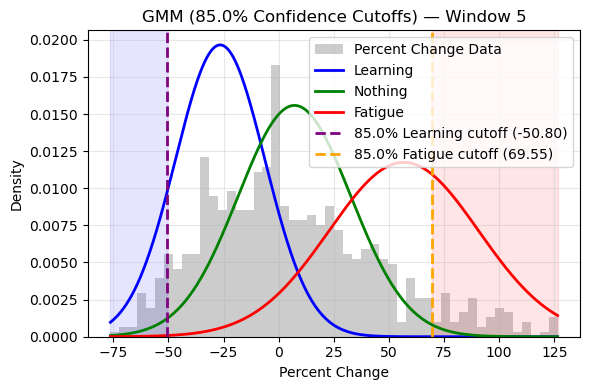

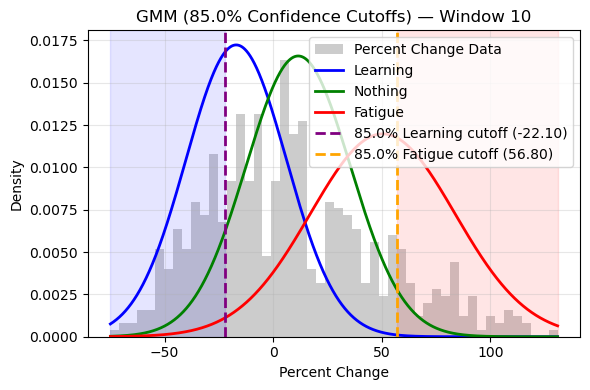

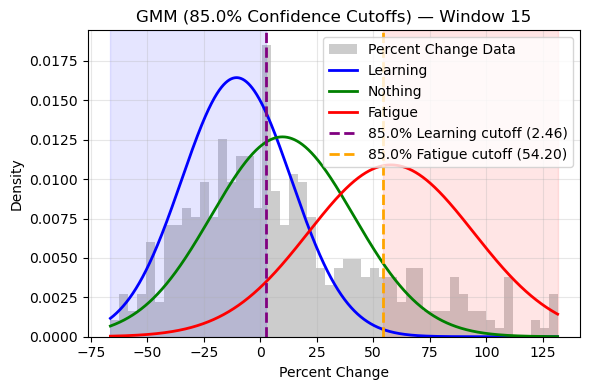

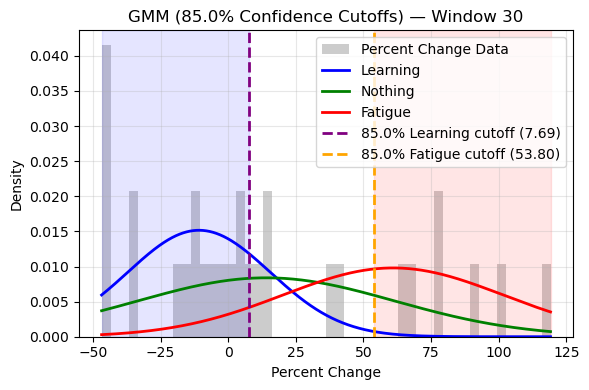

In [ ]:
for window in window_sizes: 
    results = gmm_results[window]
    means = results["means"]
    sigmas = results["sigmas"]
    percents = percent_dict[window]

    # compute Gaussian PDFs
    x = np.linspace(np.nanmin(percents), np.nanmax(percents), 10000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    
    # extract confidence cutoffs
    t_learning = thresholds[window]["learning_cutoff"]
    t_fatigue = thresholds[window]["fatigue_cutoff"]

    # plot histogram
    plt.figure(figsize=(6, 4))
    plt.hist(percents, bins=50, density=True, alpha=0.4, color='gray', label='Percent Change Data')

    # plot Gaussians
    colors = ['blue', 'green', 'red']
    labels = ['Learning', 'Nothing', 'Fatigue']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)

    # shaded regions for high-confidence areas
    if not np.isnan(t_learning):
        plt.axvspan(x.min(), t_learning, color='blue', alpha=0.1)
    if not np.isnan(t_fatigue):
        plt.axvspan(t_fatigue, x.max(), color='red', alpha=0.1)

    # plot confidence cutoffs
    if not np.isnan(t_learning):
        plt.axvline(t_learning, color='purple', linestyle='--', lw=2, label=f'{conf_percent} Learning cutoff ({t_learning:.2f})')
    if not np.isnan(t_fatigue):
        plt.axvline(t_fatigue, color='orange', linestyle='--', lw=2, label=f'{conf_percent} Fatigue cutoff ({t_fatigue:.2f})')

    
    plt.title(f"GMM ({conf_percent} Confidence Cutoffs) — Window {window}")
    plt.xlabel("Percent Change")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Ensure GMM thresholds are statistically significant

### H0 = The percent change at or beyond the calculated threshold is due to random variation

### H1 = The percent change at or beyond the calculated threshold is not due to random variation

In [ ]:
for w, t in thresholds.items():
    print(Fore.CYAN + f"Window {w}: mean percent change is {statistics.mean(percent_dict[w])}")
    t_stat, p_value = stats.ttest_1samp(percent_dict[w], t['learning_cutoff'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Learning threshold = {t['learning_cutoff']:.4f} is statistically significant with a p-value of {p_value}") 
    else:
        print(Fore.RED + f"Learning threshold = {t['learning_cutoff']:.4f} is NOT statistically significant with a p-value of {p_value}")
    t_stat, p_value = stats.ttest_1samp(percent_dict[w], t['fatigue_cutoff'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Fatigue threshold = {t['fatigue_cutoff']:.4f} is statistically significant with a p-value of {p_value}")
    else:
        print(Fore.RED + f"Fatigue threshold = {t['fatigue_cutoff']:.4f} is NOT statistically significant with a p-value of {p_value}")

print("NOTE: Only using learning values.")

Window 5: mean percent change is 5.436788362497065
Learning threshold = -50.7954 is statistically significant with a p-value of 3.7042521724309664e-185
Fatigue threshold = 69.5470 is statistically significant with a p-value of 3.024189963528102e-215
Window 10: mean percent change is 8.036484779002096
Learning threshold = -22.0988 is statistically significant with a p-value of 1.1419477999037574e-62
Fatigue threshold = 56.8020 is statistically significant with a p-value of 1.5929222495942255e-124
Window 15: mean percent change is 10.484259229824783
Learning threshold = 2.4633 is statistically significant with a p-value of 4.782671354692703e-05
Fatigue threshold = 54.2020 is statistically significant with a p-value of 1.0603359723810453e-75
Window 30: mean percent change is 13.97480002240476
Learning threshold = 7.6926 is NOT statistically significant with a p-value of 0.48280546377282885
Fatigue threshold = 53.8014 is statistically significant with a p-value of 0.00010599206319421592


## Visualize thresholds in trials

### Prepare for visualization

In [53]:
window = 10 # size of window - user determined

In [ ]:
learning_threshold = thresholds[window]["learning_cutoff"]
print(f"Learning threshold: {learning_threshold}")

fatigue_threshold = thresholds[window]["fatigue_cutoff"]
print(f"Fatigue threshold: {fatigue_threshold}")

modes_list = []

for i, row in df_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        
        start_val = errors[start]

        end_val = errors[start + window - 1]

        percent_changed = get_change(start_val, end_val)

        if percent_changed < learning_threshold:
            subject_modes.append("learning")
        elif percent_changed > fatigue_threshold:
            subject_modes.append("fatigued")
        else:
            subject_modes.append("nothing")
    
    # pad the beginning so the mode array is same length as trials - no reading at the beginning
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=df_clean.index, columns=df_clean.columns)

Learning threshold: -22.09879380287088
Fatigue threshold: 56.80201138503047


### Visualize at given window

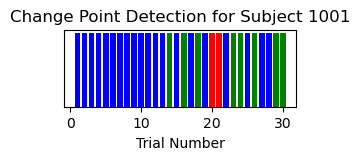

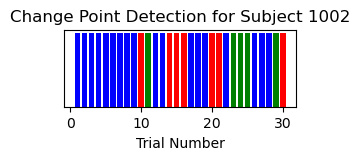

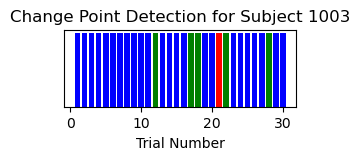

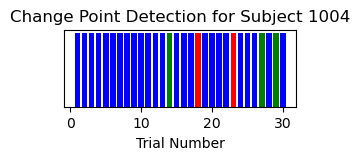

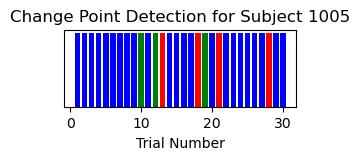

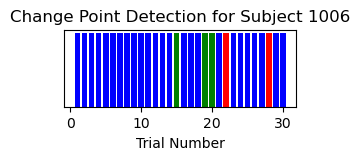

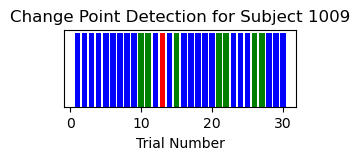

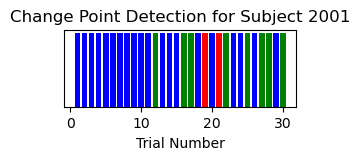

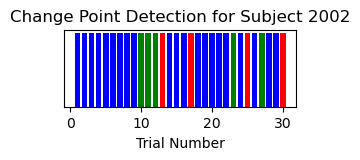

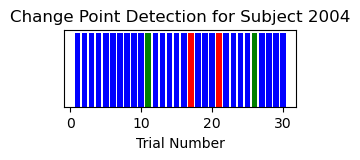

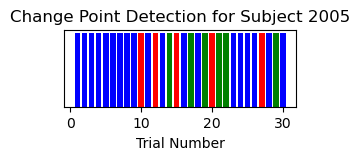

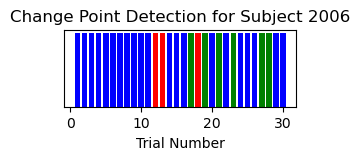

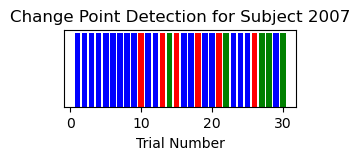

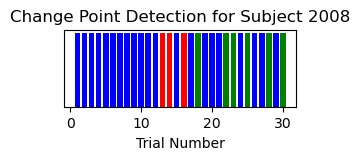

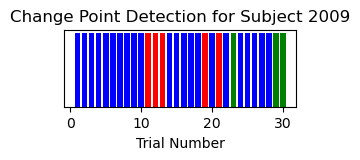

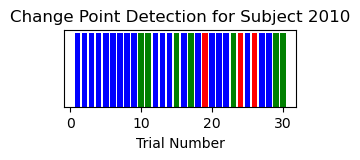

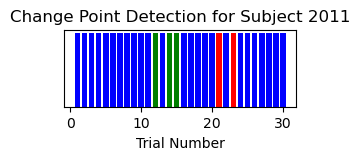

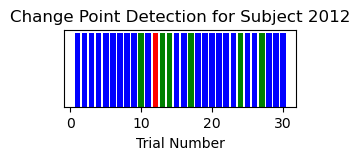

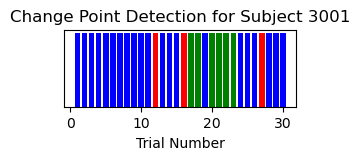

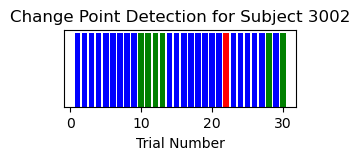

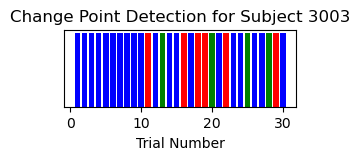

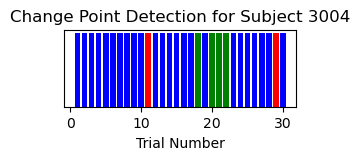

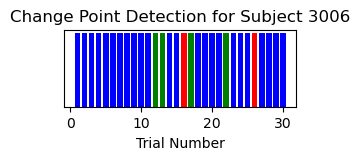

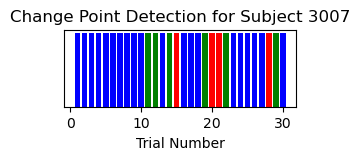

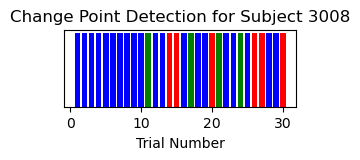

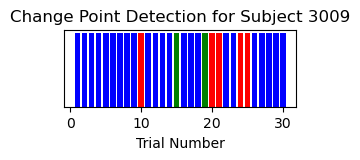

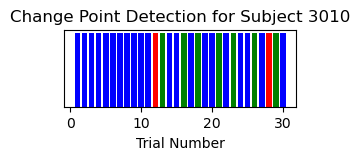

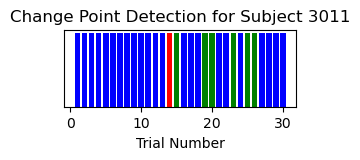

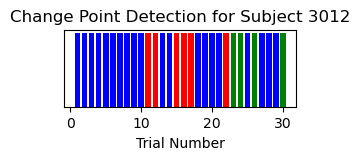

In [55]:
for i in range(0,raw_df.shape[0]):
    subject = i
    colors = {"learning": "green", "nothing": "blue", "fatigued": "red"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(3,1))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {df_clean.index[subject]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()

# Detect inconsistency

## Calculate the variance at every window

In [66]:
if not small_only:
    window_sizes = [4, 8, 12, 16, 20, 40]
else:
    window_sizes = [5, 10, 15, 30]

variance_dict = {}
high_var_thresholds = {}
desired_percentile = 75

for window in window_sizes:
    all_variances = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            window_vals = errors[start:start + window]
            var = np.var(window_vals, ddof=1)
            all_variances.append(var)

    variance_dict[window] = np.array(all_variances)


    high_var_threshold = np.percentile(all_variances, desired_percentile)
    high_var_thresholds[window] = high_var_threshold
    print(f"Window {window}: {str(desired_percentile)}th percentile variance cutoff = {high_var_threshold:.4f}")

Window 5: 75th percentile variance cutoff = 0.0022
Window 10: 75th percentile variance cutoff = 0.0023
Window 15: 75th percentile variance cutoff = 0.0023
Window 30: 75th percentile variance cutoff = 0.0020


In [67]:
window = 10

In [ ]:
learning_threshold = thresholds[window]["learning_cutoff"]
print(f"Learning threshold: {learning_threshold}")

fatigue_threshold = thresholds[window]["fatigue_cutoff"]
print(f"Fatigue threshold: {fatigue_threshold}")

variance_threshold = high_var_thresholds[window]
print(f"Variance threshold: {variance_threshold}")

modes_list = []

for i, row in df_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        
        start_val = errors[start]

        end_val = errors[start + window - 1]

        percent_changed = get_change(start_val, end_val)

        if window_variance >= variance_threshold: # variance trumps everything
            subject_modes.append("inconsistent")
        elif percent_changed < learning_threshold:
            subject_modes.append("learning")
        elif percent_changed > fatigue_threshold:
            subject_modes.append("fatigued")
        else:
            subject_modes.append("nothing")

        window_variance = np.var(window_vals, ddof=1)

        
    
    # pad the beginning so the mode array is same length as trials
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=df_clean.index, columns=df_clean.columns)

Learning threshold: -22.09879380287088
Fatigue threshold: 56.80201138503047
Variance threshold: 0.0023288070160626877


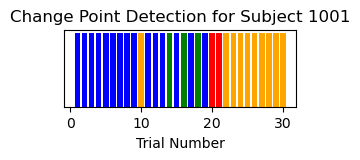

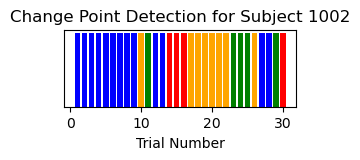

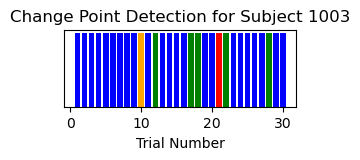

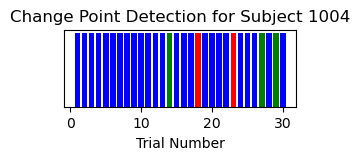

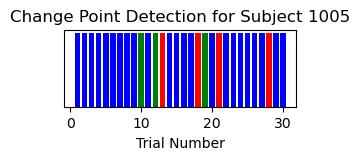

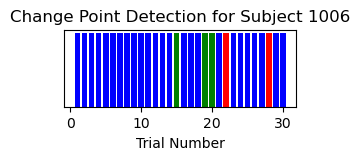

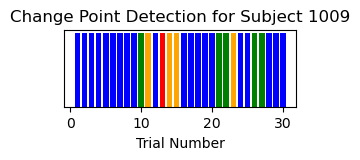

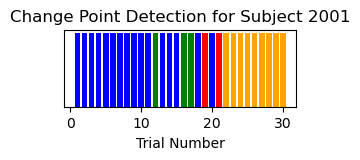

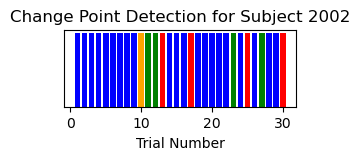

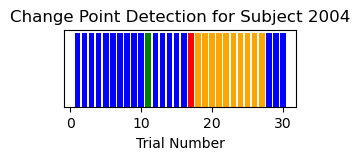

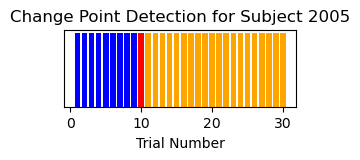

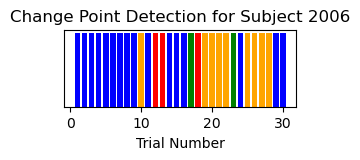

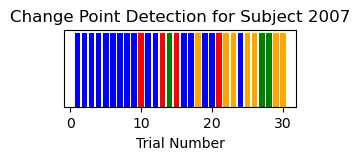

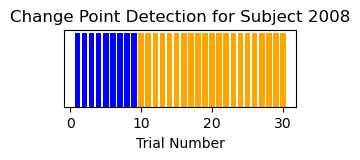

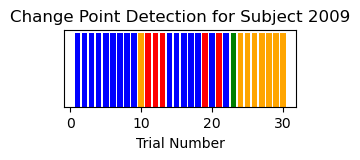

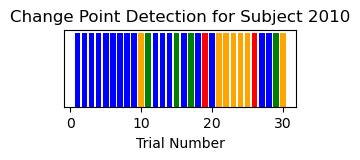

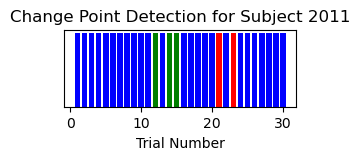

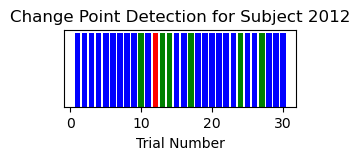

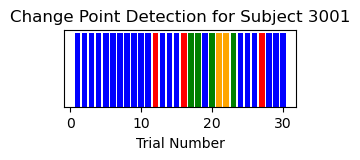

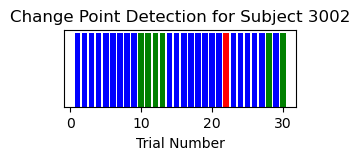

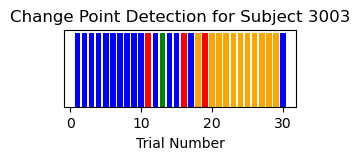

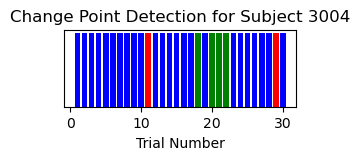

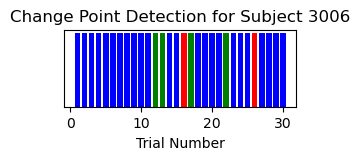

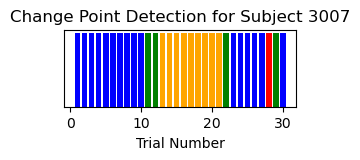

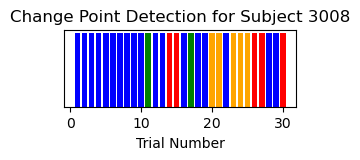

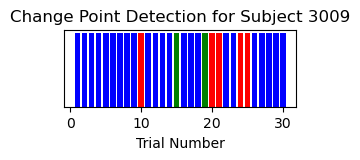

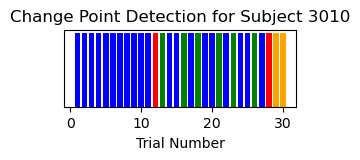

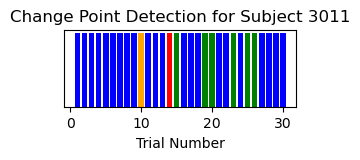

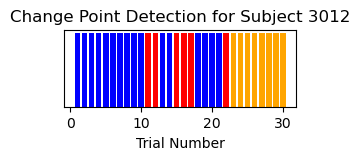

In [69]:
for i in range(0,raw_df.shape[0]):
    subject = i
    colors = {"learning": "green", "nothing": "blue", "fatigued": "red", "inconsistent": "orange"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(3,1))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {df_clean.index[subject]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()

## Use GMM to find threshold for inconsistency

In [ ]:
var_desired_probability = .6
var_conf_percent = str(var_desired_probability * 100) + "%"

var_thresholds = {}
var_gmm_results = {}

for window, variance in variance_dict.items():
    vars_reshaped = variance.reshape(-1, 1) # reshape the variances
    gmm = BayesianGaussianMixture(n_components=2, n_init=100, tol=0.001) # create GMM
    gmm.fit(vars_reshaped) # fit the GMM to the data
    
    # sort components
    means = gmm.means_.flatten()

    sigmas = np.sqrt(gmm.covariances_.flatten())

    order = np.argsort(means)
    means, sigmas, weights = means[order], sigmas[order], gmm.weights_[order]
    
    # compute posteriors over value range
    x = np.linspace(np.min(variance), np.max(variance), 10000)
    # probability distribution function
    pdfs = np.array([w * norm.pdf(x, m, s) for w, m, s in zip(weights, means, sigmas)])
    denom = np.sum(pdfs, axis=0)
    
    denom[denom == 0] = 1e-12
    posteriors = pdfs / denom
    
    # confidence threshold
    # inconsistent group is index 1
    if np.any(posteriors[1] >= var_desired_probability):
        inconsistent_cutoff = x[np.where(posteriors[1] >= var_desired_probability)[0][-1]]
    else:
        inconsistent_cutoff = np.nan


    var_thresholds[window] = {
        "inconsistent_cutoff": inconsistent_cutoff,
        "means": means,
    }
    var_gmm_results[window] = {"means": means, "sigmas": sigmas, "weights": weights}

# display thresholds
for w, t in var_thresholds.items():
    print(f"Window {w}:")
    print(f"  {var_conf_percent} Inconsistent cutoff: {t['inconsistent_cutoff']:.4f}")

Window 5:
  60.0% Inconsistent cutoff: 0.0097
Window 10:
  60.0% Inconsistent cutoff: 0.0063
Window 15:
  60.0% Inconsistent cutoff: 0.0044
Window 30:
  60.0% Inconsistent cutoff: 0.0034


### Display GMM consistency findings

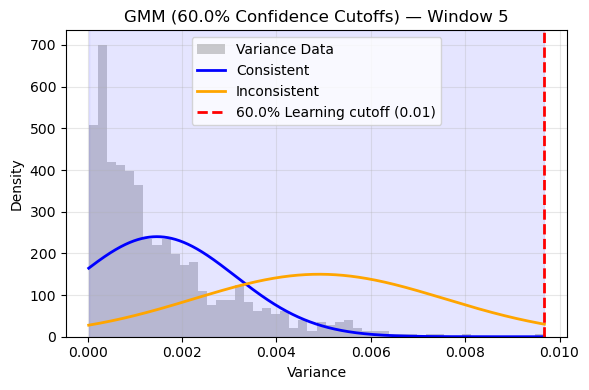

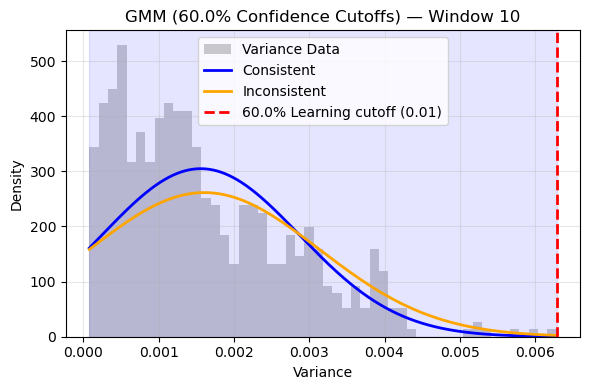

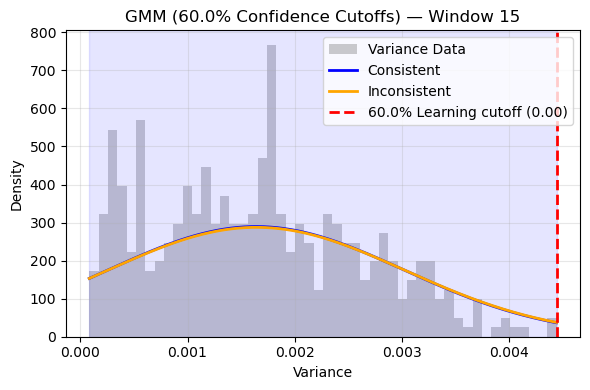

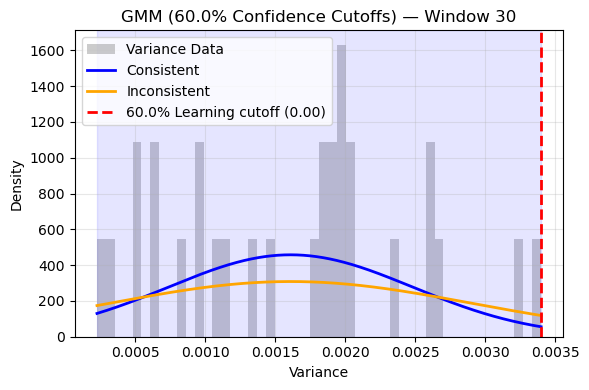

In [ ]:
for window in window_sizes: 
    results = var_gmm_results[window]
    means = results["means"]
    sigmas = results["sigmas"]
    variances = variance_dict[window]

    # compute Gaussian PDFs
    x = np.linspace(np.nanmin(variances), np.nanmax(variances), 10000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    
    # extract confidence cutoffs
    t_inconsistent = var_thresholds[window]["inconsistent_cutoff"]

    # plot histogram
    plt.figure(figsize=(6, 4))
    plt.hist(variances, bins=50, density=True, alpha=0.4, color='gray', label='Variance Data')

    # plot Gaussians
    colors = ['blue','orange']
    labels = ['Consistent', 'Inconsistent']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)

    # shaded regions for high-confidence areas
    if not np.isnan(t_inconsistent):
        plt.axvspan(x.min(), t_inconsistent, color='blue', alpha=0.1)

    # plot confidence cutoff
    if not np.isnan(t_inconsistent):
        plt.axvline(t_inconsistent, color='red', linestyle='--', lw=2,
                    label=f'{var_conf_percent} Learning cutoff ({t_inconsistent:.2f})')

    
    plt.title(f"GMM ({var_conf_percent} Confidence Cutoffs) — Window {window}")
    plt.xlabel("Variance")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()